In [1]:
from imd_features.config import FeatureSetConfig, GroupConfig
from imd_features.process import create_feature_set
from project_paths import paths

input_file = paths.input_file

In [4]:

minimum_config = FeatureSetConfig(
    name="minimum_curated",
    description="no reduction and the bare minimum features i think have enough information to predict imd",
    groups={
        "uc": GroupConfig(columns=["total_claims"]),
        "crime": GroupConfig(columns=["violent-crime", "total_crimes"]),
        "land_registry": GroupConfig(columns=["lsoa_mean_price", "total_transactions"]),
        "connectivity": GroupConfig(columns=["Overall"]),
        "osm": GroupConfig(columns=["landuse_residential_0"]),
    },
)

df_minimum, metadata = create_feature_set(input_file, minimum_config)

In [5]:
medium_config_path = paths.output / "calibrated_reduction_a5381280_config.json"
medium_config = FeatureSetConfig.model_validate_json(medium_config_path.read_text())
df_medium, _ = create_feature_set(input_file, medium_config)

In [13]:
from pathlib import Path
from project_paths import project_root

eng_rates_path = paths.output / "engineered_rates_v2_c3ad0464_config.json"
eng_config = FeatureSetConfig.model_validate_json(eng_rates_path.read_text())
df_eng, _ = create_feature_set(project_root / "data/input/combined_engineered.parquet", eng_config)

ive chosen to use three different configs.
The minimum config because these are the fewest features i think we can use to capture enough information to do some prediction, and this gives us the highest ratio of observations to features.
The medium config is the calibrated reduction config, which has lots of features selected and reduced. This one performs well on the leaderboard.
The engineered rates, where linear rates have been precomuted. These should be especially useful in a regression model that may not learn these interactions itself.

We already know that the undreduced configs completely fail (curse of dimensionality). We can also be pretty confident that overfitting is occuring in the highest performing rf models. What we want to learn here is, when the dimensionality is well handled, is the ~0.7 r2 of the ridge model a ceiling, and if so is it because of too few observations (n = 263 currently) or because of the quality of features, or both.



In [14]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import clone
from sklearn.metrics import r2_score
from scipy.stats import spearmanr


In [15]:

RANDOM_SEED = 123
N_CV_FOLDS = 5
TARGET_COL = "score"

target_df = pl.read_parquet(paths.reference)

In [16]:

def load_XY(features_df: pl.DataFrame):
    combined = features_df.join(target_df, on="lsoa_code", how="inner")
    feature_cols = [c for c in features_df.columns if c != "lsoa_code"]
    X = combined.select(feature_cols).to_numpy()
    y = combined.select(TARGET_COL).to_numpy().ravel()
    return X, y, feature_cols

In [ ]:
#

In [37]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 500, 1000]

def ridge_alpha_sweep(X, y, alphas, n_splits=5):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    train_r2s, test_r2s = [], []
    
    for alpha in alphas:

        fold_train, fold_test = [], []

        for train_idx, test_idx in kf.split(X):

            model = Ridge(alpha=alpha)
            model.fit(X[train_idx], y[train_idx])
            fold_train.append(r2_score(y[train_idx], model.predict(X[train_idx])))
            fold_test.append(r2_score(y[test_idx], model.predict(X[test_idx])))

        train_r2s.append(np.mean(fold_train))
        test_r2s.append(np.mean(fold_test))
    
    return np.array(train_r2s), np.array(test_r2s)



In [38]:
X, y, feature_cols = load_XY(df_minimum)

min_train_r2s, min_test_r2s = ridge_alpha_sweep(X, y, alphas)



In [39]:
X, y, feature_cols = load_XY(df_medium)

med_train_r2s, med_test_r2s = ridge_alpha_sweep(X, y, alphas)


In [40]:
X, y, feature_cols = load_XY(df_eng)

eng_train_r2s, eng_test_r2s = ridge_alpha_sweep(X, y, alphas)


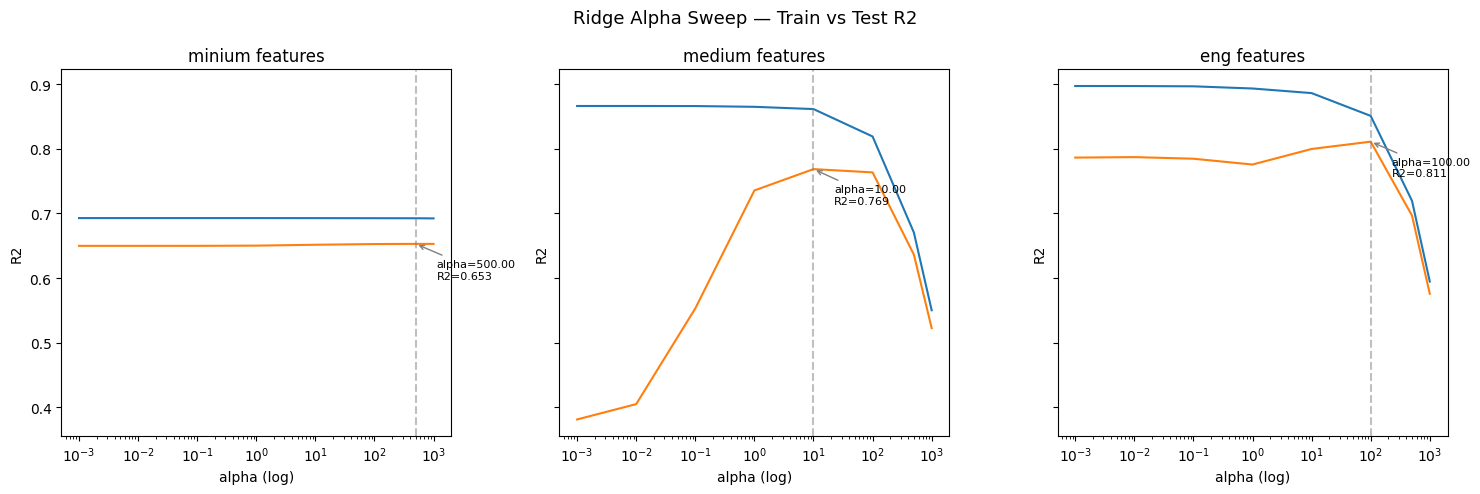

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
ax1, ax2, ax3 = axes


ax1.plot(alphas, min_train_r2s, label="Train R2", linewidth=1.5)
ax1.plot(alphas, min_test_r2s, label="Test R2 (CV)", linewidth=1.5)

best_min = np.argmax(min_test_r2s)
ax1.axvline(alphas[best_min], color="grey", linestyle="--", alpha=0.5)
ax1.annotate(
    f"alpha={alphas[best_min]:.2f}\nR2={min_test_r2s[best_min]:.3f}",
    xy=(alphas[best_min], min_test_r2s[best_min]),
    xytext=(15, -25),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax1.set_xscale("log")
ax1.set_xlabel("alpha (log)")
ax1.set_ylabel("R2")
ax1.set_title("minium features")



ax2.plot(alphas, med_train_r2s, label="Train R2", linewidth=1.5)
ax2.plot(alphas, med_test_r2s, label="Test R2 (CV)", linewidth=1.5)

best_med = np.argmax(med_test_r2s)
ax2.axvline(alphas[best_med], color="grey", linestyle="--", alpha=0.5)
ax2.annotate(
    f"alpha={alphas[best_med]:.2f}\nR2={med_test_r2s[best_med]:.3f}",
    xy=(alphas[best_med], med_test_r2s[best_med]),
    xytext=(15, -25),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax2.set_xscale("log")
ax2.set_xlabel("alpha (log)")
ax2.set_ylabel("R2")
ax2.set_title("medium features")



ax3.plot(alphas, eng_train_r2s, label="Train R2", linewidth=1.5)
ax3.plot(alphas, eng_test_r2s, label="Test R2 (CV)", linewidth=1.5)

best_eng = np.argmax(eng_test_r2s)
ax3.axvline(alphas[best_eng], color="grey", linestyle="--", alpha=0.5)
ax3.annotate(
    f"alpha={alphas[best_eng]:.2f}\nR2={eng_test_r2s[best_eng]:.3f}",
    xy=(alphas[best_eng], eng_test_r2s[best_eng]),
    xytext=(15, -25),
    textcoords="offset points",
    fontsize=8,
    arrowprops=dict(arrowstyle="->", color="grey"),
)
ax3.set_xscale("log")
ax3.set_xlabel("alpha (log)")
ax3.set_ylabel("R2")
ax3.set_title("eng features")

fig.suptitle("Ridge Alpha Sweep — Train vs Test R2", fontsize=13)
fig.tight_layout()
plt.savefig("alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

In [42]:
train_sizes = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# At n=263 these correspond to roughly: 42, 63, 84, 105, 131, 158, 184, 210 training LSOAs

def learning_curve(X, y, model, train_sizes, n_seeds=10, n_splits=5):

    results = {s: [] for s in train_sizes}
    n = len(y)
    
    for seed in range(n_seeds):
        rng = np.random.default_rng(seed)
        for frac in train_sizes:
            n_train = int(n * frac)
            idx = rng.permutation(n)
            train_idx, test_idx = idx[:n_train], idx[n_train:]
            
            m = clone(model)
            m.fit(X[train_idx], y[train_idx])
            results[frac].append(r2_score(y[test_idx], m.predict(X[test_idx])))
    
    means = np.array([np.mean(results[s]) for s in train_sizes])
    stds = np.array([np.std(results[s]) for s in train_sizes])
    return means, stds


In [43]:
X, y, feature_cols = load_XY(df_minimum)
min_means, min_stds = learning_curve(X, y, Ridge(1000), train_sizes)

In [44]:
X, y, feature_cols = load_XY(df_medium)
med_means, med_stds = learning_curve(X, y, Ridge(10), train_sizes)

In [45]:
X, y, feature_cols = load_XY(df_eng)
eng_means, eng_stds = learning_curve(X, y, Ridge(100), train_sizes)

In [48]:
train_ns = [int(i) for i in train_sizes*263]
train_ns

[52, 78, 105, 131, 157, 184, 210, 236]

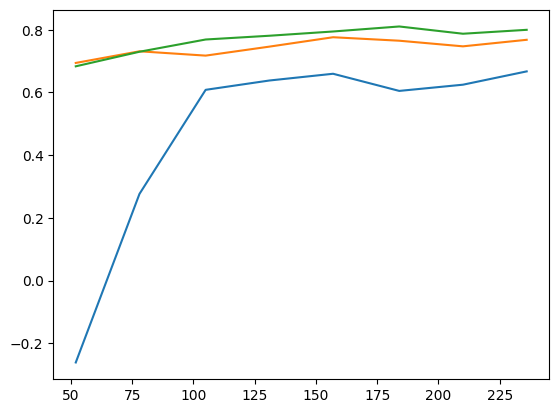

In [55]:
ax = plt.axes()


ax.plot(train_ns, min_means)
ax.plot(train_ns, med_means)
ax.plot(train_ns, eng_means)

plt.show()

in this notebook, i think I have demonstrated two things:

1. overfitting is definitly happening and needs to be considered carefully. The gap between the test r2 score and train r2 score shows that the model is learning some pattern that isn't generalizable to the rest of the data. The alpha regularization starts to combat overfitting, but it never succeeds in closing the gap before the performance of the model starts to deteriorate. 

2. the learning rates show that r2 hasn't completely plataued by the time we exhaust all our training examples. This isn't totally clear, but plausible enough to be explored data.

The presence of overfitting was expected, since we have a few known problems:
    - our observations will never be independent, although this is an assumption of most ml models. We have discussed this (spatial leakage) and it seems that this is pretty much unavoidable for our problem
    - our features are likely to be colinear
    - we have a low sample size for observations (n-262 total, so about ~225 in any given fold)

We saw initial evidence of overfitting because of the performance gap between ridge and random forest in the baseline models used in the leaderboard (RF is known to overfit quickly while ridge is more resistant), and also from how suspiciously good the results were with no tuning.

What was unknown at the beginning was the extent of these problems and what next steps would be appropriate for mitigating them. It could either have been a feature problem (all multicolinear and models cant learn anything from them), or a dataset problem (n too small or the non independence of the observations is too big an issue to be handled by these models).

In the alpha sweep plot, we see the gap between test and train r2 reduce but not completely close before the model starts to fail, meaning regularization is helping with overfitting but not solving it. 
There is basically no affect on the minimal features, which is exactly what we expect since we selected few enough fatures that there should be no disproportionately large coefficients that are penalized. 
The test r2 is already above 0.5 for this minimal feature set, which suggests that there is already some information in just a few features (good thing), but there is also still a gap meaning overfitting could be present even in this simplest iteration. I think this suggests that the low sample size is responsible for part of the problem straight away.
I think its interesting how much more overfit the calibrated features config is than the engineered features config at low alpha values. Not sure exactly why this is.
The engineered features being the highest performing overall makes sense since these include interactions (rates and ratios) that ridge regression doesn't learn by itself (rf theoretically could). So it actually includes new signal.
I think it would be interesting to try again with one more feature config that uses much more factor analysis as a reduction technique and compare the curve to the selection driven approach in this version of the calibrated features.

The second plot is the learning rate.
For the simplest model, we see that the r2 is bad until we reach 100 examples and then climbs slowly. I think the curves for all of them are still trending up at the end, but harry thinks its inconclusive right now. For all three feature configs, the shape of the curve between 100 and 225 is very similar. Does this mean that the pattern of adding the same lsoas has the same affect on all three models? 

In my opinion, these findings inform our next steps in the following ways:

1. We should proritize getting the 2019 snapshot ready so we can train on all the 2019 data and test on the 2025 data. We need to consider temporal leakage when using both (should 2025 just be a validation split not a test split?). But we should be able to increase training observations from ~225 up to the full 263. We can see if this has a positive effect on the r2.

2. We should consider collecting data from similar cities to bristol (how we decide on similar tbd) and using this to train our model. The data pipeline can probably be parameterized to fetch a dataset for a different city with 1 or 2 days of refactor work. This is going to be valuable not only to improve our model but demonstrate the extensibility of our project

3. We need to train models very conciously to avoid overfitting problems. For example, when training a random forest we should make the trees very shallow and have lots of trees in the forest (and something about leaf node size i think, need to reread esl book)

4. This pretty much rules out any deep learning techniques. If we can't even get to the highest potential result of the simplest linear models with this sample size then we have no chance of getting a good graph neural network or other data hungry model

5. We should revist a spatially aware econometric model as a baseline. A non machine learning statistical model as a comparison will help contextualize the overfitting problem. We then need to compare any ml approaches to this and explain:
    a. if we think any improvement is due to genuine better performance or to overfitting
    b. if we think any increased risk of overfitting is a good trade off.
A model like spatial lag is simple and is designed to handle the non independence (spatial autocorrelation) of the observations. So its going to be a really valuable benchmark from this point of view as well.
